# LSST KN Simulation Pipeline

Forward-model KN light curves with the Rubin/LSST 10-year baseline cadence using `lightcurvelynx`.

**Survey**: LSST baseline v5.3.0 OpSim (`baseline_v5.3.0_10yrs.db`)  
**Model**: KN from redback
**Filters**: u, g, r, i, z, y  
**Redshift**: volumetric rate 1×10^−6yr^−1Mpc^−3 (Scolnic et al. 2018a), z = 0.001–0.4  
**Parameters**: Gaussian priors for x1 and c (no pzflow, no host galaxy)

## 1. Imports

## 0. Environment Setup

No need to set `LIGHTCURVELYNX_DATA_DIR` — the default cache at `~/.cache/lightcurvelynx` is used.  
The OpSim v5.3.0 database is already downloaded there.

In [1]:
# auto reload
%load_ext autoreload
%autoreload 2

In [2]:
from lightcurvelynx import _LIGHTCURVELYNX_DOWNLOAD_DATA_DIR
print(f"Data dir: {_LIGHTCURVELYNX_DOWNLOAD_DATA_DIR}")

Data dir: /Users/mi/.cache/lightcurvelynx


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import interp1d

from lightcurvelynx.obstable.opsim import OpSim
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.snia_utils import (
    DistModFromRedshift,
    X0FromDistMod,
    num_snia_per_redshift_bin,
)
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableUniformRADECSampler,ApproximateMOCSampler
from lightcurvelynx.models.redback_models import RedbackWrapperModel
from lightcurvelynx.astro_utils.dustmap import SFDMap
from lightcurvelynx.effects.extinction import ExtinctionEffect
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.utils.extrapolate import LinearDecayOnMag,ZeroPadding

from redback import model_library
from redback.priors import get_priors

No module named 'lalsimulation'
lalsimulation is not installed. Some EOS based models will not work. Please use bilby eos or pass your own EOS generation class to the model
swifttools not available. You will not be able to download Swift afterglow data via API.
19:44 bilby INFO    : Running bilby version: 2.6.0
19:44 redback INFO    : Running redback version: 1.16.0


## 2. Simulation Configuration

In [4]:
SEED = 1024
RNG  = np.random.default_rng(SEED)

SIM_PARAMS = {
    # Cosmology
    "H0": 70.0,
    "Omega_m": 0.315,
    "w": -1.0,
    # Redshift range
    "zmin": 0.001,
    "zmax": 0.4,
    "znbins": 100,
    # Tripp relation coefficients
    "alpha": 0.15,
    "beta": 3.15,
    # SALT3 Gaussian priors (no pzflow, no host galaxy)
    "x1_mean": 0.973,  "x1_sigma_minus": 1.472, "x1_sigma_plus": 0.222,
    "c_mean":  -0.054,  "c_sigma_minus":  0.043, "c_sigma_plus":  0.101,
    "m_abs_mean": -19.3, "m_abs_sigma": 0.1,
    # Survey
    "filters": ["u", "g", "r", "i", "z", "y"],
    "sky_coverage": 18_000.0,  # placeholder; overwritten from opsim
}

## 3. Load LSST OpSim

The file is downloaded once and cached locally by `OpSim.from_url()`.

In [5]:
opsim_path = _LIGHTCURVELYNX_DOWNLOAD_DATA_DIR / "opsim" / "baseline_v5.0.1_10yrs.db"
opsim = OpSim.from_db(
    opsim_path,
    sql_query="SELECT * FROM observations WHERE scheduler_note NOT LIKE 'DD:%'",
)
print(f"OpSim loaded: {len(opsim):,} observations")
print(f"MJD range: {opsim['time'].min():.1f} – {opsim['time'].max():.1f}")
print(f"Filters:    {sorted(opsim['filter'].unique())}")

OpSim loaded: 1,947,898 observations
MJD range: 60981.0 – 64632.3
Filters:    ['g', 'i', 'r', 'u', 'y', 'z']


In [6]:
# sky_coverage = opsim.estimate_coverage()    
sky_coverage = 28148 #deg
SIM_PARAMS["sky_coverage"] = sky_coverage
print(f"Estimated sky coverage: {sky_coverage:.0f} deg²")

Estimated sky coverage: 28148 deg²


## 4. Calculate Number of SNe to Simulate

Integrate the volumetric SN Ia rate over the survey volume and duration:
$$N = \int_{z_{\rm min}}^{z_{\rm max}} r_v(z)\,\frac{dV}{dz}\,\frac{dz}{1+z} \times \Omega \times T_{\rm survey}$$

In [7]:
t_min = float(opsim["time"].min())
t_max = float(opsim["time"].max())
SIM_PARAMS["tmin"] = t_min
SIM_PARAMS["tmax"] = t_max

survey_length = (t_max - t_min) / 365.25
print(f"Survey length = {survey_length:.2f} years")

solid_angle = SIM_PARAMS["sky_coverage"] * (np.pi / 180.0) ** 2
print(f"Solid angle   = {solid_angle:.4f} sr  ({SIM_PARAMS['sky_coverage']:,.0f} deg²)")

rate = lambda z:1.0e-6 # yr⁻¹ Mpc⁻³
nsntotal, _ = num_snia_per_redshift_bin(
    SIM_PARAMS["zmin"],
    SIM_PARAMS["zmax"],
    znbins=1,
    solid_angle=solid_angle,
    vol_rate_function=rate,
    H0=SIM_PARAMS["H0"],
    Omega_m=SIM_PARAMS["Omega_m"],
)
nsn = int(nsntotal[0] * survey_length)
print(f"Expected KN = {nsn:,}")

nsn = int(nsn * 1.0)
print(f"Expected KN (100%) = {nsn:,}")

Survey length = 10.00 years
Solid angle   = 8.5744 sr  (28,148 deg²)
Expected KN = 81,820
Expected KN (100%) = 81,820


## 5. Load LSST Passbands

In [8]:
passbands = PassbandGroup.from_preset("LSST", filters=SIM_PARAMS["filters"])
print(passbands)

PassbandGroup containing 6 passbands: LSST_u, LSST_g, LSST_r, LSST_i, LSST_z, LSST_y


## 6. Redshift Distribution (Volumetric Rate)

Use the Frohmaier et al. (2019) volumetric rate $r_v(z) = r_0\,(1+z)^\alpha$ to compute the
expected number of SNe Ia per redshift bin, then build an interpolated PDF for sampling.

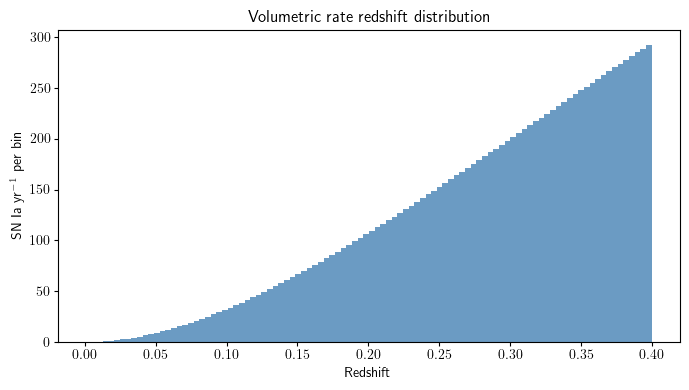

In [9]:
nsn_per_bin, z_mean = num_snia_per_redshift_bin(
    SIM_PARAMS["zmin"],
    SIM_PARAMS["zmax"],
    SIM_PARAMS["znbins"],
    H0=SIM_PARAMS["H0"],
    Omega_m=SIM_PARAMS["Omega_m"],
    vol_rate_function=rate,
)
zpdf = interp1d(z_mean, nsn_per_bin, bounds_error=False, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 4))
dz = (SIM_PARAMS["zmax"] - SIM_PARAMS["zmin"]) / SIM_PARAMS["znbins"]
ax.bar(z_mean, nsn_per_bin, width=dz, color="steelblue", alpha=0.8)
ax.set(xlabel="Redshift", ylabel="SN Ia yr$^{-1}$ per bin",
       title="Volumetric rate redshift distribution")
plt.tight_layout()
plt.show()

## 7. Build KN Source Model

Parameter graph:
- **RA, Dec** — uniformly sampled from the observed LSST footprint (`ObsTableUniformRADECSampler`)
- **redshift** — drawn from the volumetric rate PDF (`SamplePDF`)

In [ ]:
# RA/Dec: uniform over the opsim footprint (rejection sampling)
# radec = ObsTableUniformRADECSampler(opsim, node_label="radec")
moc = opsim.build_moc(max_depth=12)
radec = ApproximateMOCSampler(moc, node_label="radec")

# Redshift from volumetric rate PDF
z_func = SamplePDF(zpdf, node_label="redshift")

rb_model = model_library.all_models_dict["one_component_kilonova_model"]

# Set the parameters that are needed by the redback model. Note that the first two are set
# from samplers, while the last three are fixed values.
parameters = {
    "mej": NumpyRandomFunc("normal", loc=0.05, scale=0.02),
    "redshift": NumpyRandomFunc("uniform", low=0.0, high=0.1),
    "temperature_floor": 3000,
    "kappa": 1,
    "vej": 0.2,
}

# Create the model itself.
source = RedbackWrapperModel(
    rb_model,
    parameters=parameters,  # Set ALL the redback model parameters
    ra=radec.ra,  # Set other parameters
    dec=radec.dec,
    t0=NumpyRandomFunc("uniform", low=t_min, high=t_max),
    node_label="source",
)

mwextinction = SFDMap(
    ra=source.ra,
    dec=source.dec,
    node_label="mwext",
)
# Create an extinction effect using the EBVs from that dust map.
ext_effect = ExtinctionEffect(extinction_model="F99", ebv=mwextinction, 
                              r_v=3.1,frame='observer',backend="dust_extinction")
source.add_effect(ext_effect)

print("Source model built successfully.")

Source model built successfully.


## 8. Run Simulation

In [11]:
opsim.columns

Index(['observationId', 'ra', 'dec', 'time', 'flush_by_mjd', 'exptime', 'band',
       'filter', 'rotation', 'rotSkyPos_desired', 'nexposure', 'airmass',
       'seeingFwhm500', 'seeing', 'seeingFwhmGeom', 'skybrightness', 'night',
       'slewTime', 'visitTime', 'slewDistance', 'maglim', 'altitude',
       'azimuth', 'paraAngle', 'pseudoParaAngle', 'cloud', 'moonAlt', 'sunAlt',
       'scheduler_note', 'target_name', 'target_id', 'observationStartLST',
       'rotTelPos', 'rotTelPos_backup', 'moonAz', 'sunAz', 'sunRA', 'sunDec',
       'moonRA', 'moonDec', 'moonDistance', 'solarElong', 'moonPhase',
       'cummTelAz', 'observation_reason', 'science_program',
       'cloud_extinction', 'zp', 'psf_footprint', 'sky_bg_e'],
      dtype='object')

In [12]:
param_cols = [
    "source.redshift",
    "source.ra",
    "source.dec",
    "source.t0",
    "source.mej",
    "source.temperature_floor",
    "source.kappa",
    "source.vej",]
obstable_save_cols = ["zp"]

parallel_executor = "loky"  # Options: "loky", "dask", None
if parallel_executor == "loky":
    try:
        import loky
        executor = loky.get_reusable_executor(max_workers=4)
        results = simulate_lightcurves(
            model=source,
            num_samples=nsn,
            survey_info=opsim,
            passbands=passbands,
            param_cols=param_cols,
            obstable_save_cols=obstable_save_cols,
            rng=RNG,
            num_jobs=4,
            batch_size=2000,
            executor=executor,
            rest_time_window_offset=(0.1, 50),
        )
    except ImportError:
        print("Loky is not installed")
elif parallel_executor == "dask":
    try:
        import dask.distributed

        with dask.distributed.Client() as client:
            print(f"Dask dashboard link: {client.dashboard_link}")
            results = simulate_lightcurves(
                model=source,
                num_samples=nsn,
                survey_info=opsim,
                passbands=passbands,
                param_cols=param_cols,
                obstable_save_cols=obstable_save_cols,
                rng=RNG,
                num_jobs=4,
                batch_size=2000,
                executor=client,
                rest_time_window_offset=(0.1, 50),
            )
    except ImportError:
        print("Dask is not installed")
else:
    executor = None
    results = simulate_lightcurves(
        model=source,
        num_samples=nsn,
        survey_info=opsim,
        passbands=passbands,
        param_cols=param_cols,
        obstable_save_cols=obstable_save_cols,
        rng=RNG,
        num_jobs=4,
        batch_size=2000,
        executor=executor,
        rest_time_window_offset=(0.1, 50),
    )
print(f"Generated {len(results)} light curves")
print(results["lightcurve"][0])

print(f"Simulated {len(results):,} SNe Ia")
results.head()

Simulating:   0%|          | 0/81820 [00:00<?, ?obj/s]No module named 'lalsimulation'
lalsimulation is not installed. Some EOS based models will not work. Please use bilby eos or pass your own EOS generation class to the model
swifttools not available. You will not be able to download Swift afterglow data via API.
19:45 bilby INFO    : Running bilby version: 2.6.0
19:45 redback INFO    : Running redback version: 1.16.0
No module named 'lalsimulation'
lalsimulation is not installed. Some EOS based models will not work. Please use bilby eos or pass your own EOS generation class to the model
swifttools not available. You will not be able to download Swift afterglow data via API.
19:45 bilby INFO    : Running bilby version: 2.6.0
19:45 redback INFO    : Running redback version: 1.16.0
No module named 'lalsimulation'
lalsimulation is not installed. Some EOS based models will not work. Please use bilby eos or pass your own EOS generation class to the model
swifttools not available. You will 

Generated 81820 light curves
             mjd filter        flux      fluxerr  flux_perfect  survey_idx  \
0   64253.318360      z  697.131961   313.234589    267.368830           0   
1   64255.220303      y  431.495173  1005.051548    266.767476           0   
..           ...    ...         ...          ...           ...         ...   
34  64293.094039      z -685.403486   354.071872     24.130660           0   
35  64293.210489      z   48.971031   242.180587     24.080722           0   

    obs_idx  is_saturated        zp  
0   1719777         False  0.939815  
1   1721240         False  2.340625  
..      ...           ...       ...  
34  1740346         False  0.956376  
35  1740606         False  0.939781  

[36 rows x 9 columns]
Simulated 81,820 SNe Ia


id          ra        dec  nobs            t0         z  source_redshift  \
0   0   86.030016 -55.103314    36  64241.514289  0.055262         0.055262   
1   1  125.521946  -8.372465    13  63631.046518  0.041395         0.041395   
2   2  321.638370  -6.967320    24  64501.879460  0.061280         0.061280   
3   3  203.405816 -23.720353    21  63350.326982  0.050291         0.050291   
4   4  275.252869  -1.191353     0  62543.901831  0.046363         0.046363   

    source_ra  source_dec     source_t0  source_mej  source_temperature_floor  \
0   86.030016  -55.103314  64241.514289    0.070207                      3000   
1  125.521946   -8.372465  63631.046518    0.036259                      3000   
2  321.638370   -6.967320  64501.879460    0.044011                      3000   
3  203.405816  -23.720353  63350.326982    0.025874                      3000   
4  275.252869   -1.191353  62543.901831    0.051907                      3000   

   source_kappa  source_vej  \
0             1         0.2   
1             1         0.2   
2             1         0.2   
3             1         0.2   
4             1         0.2   

                                          lightcurve  \
0  [{mjd: 64253.31836, filter: 'z', flux: 697.131...   
1  [{mjd: 63643.094097, filter: 'y', flux: -1218....   
2  [{mjd: 64514.335218, filter: 'g', flux: -103.6...   
3  [{mjd: 63351.233561, filter: 'z', flux: 3659.7...   
4                                               None   

                                              params  
0  {'radec.ra': 86.0300163355615, 'radec.dec': -5...  
1  {'radec.ra': 125.5219461489469, 'radec.dec': -...  
2  {'radec.ra': 321.63836957886815, 'radec.dec': ...  
3  {'radec.ra': 203.40581584721804, 'radec.dec': ...  
4  {'radec.ra': 275.2528694830835, 'radec.dec': -...

## 9. Apply Selection Cuts

Apply detection, saturation, and quality cuts to the simulated light curves.

In [13]:
# Drop light curves with no observations
lightcurves = results.dropna(subset=['lightcurve'])

# Compute SNR and detection flag
lightcurves['lightcurve.snr'] = lightcurves['lightcurve.flux'] / lightcurves['lightcurve.fluxerr']
detection_snr_thres = 5.0
lightcurves['lightcurve.detection_flag'] = lightcurves['lightcurve.snr'] > detection_snr_thres

# Drop saturated observations
lightcurves_after_drop_sat = lightcurves.query("lightcurve.is_saturated == False").dropna(subset=['lightcurve'])

# Apply detection cut
print("Before detection cut: nsn =", len(lightcurves))
lightcurves_after_detection = lightcurves_after_drop_sat.query("lightcurve.detection_flag == True").dropna(subset=['lightcurve'])
print("After detection cut:  nsn =", len(lightcurves_after_detection))

# Quality cuts: >=7 unique phases in [-10, 40] days, >=2 pre-peak, >=3 post-peak, >=2 bands
def lc_quality_cuts(flux, mjd, filter, z, t0,
                    n_phases=5, n_before_peak=0, n_after_peak=1, n_bands=1):
    phases = np.floor((mjd - t0) / (1.0 + z))
    unique_phases, unique_idx = np.unique(phases, return_index=True)
    good_idx = (unique_phases >= -10) & (unique_phases <= 40)
    if np.sum(good_idx) == 0:
        return {"pass_quality_cuts": False}
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    pass_cut &= np.sum(unique_phases[good_idx] < 0) >= n_before_peak
    pass_cut &= np.sum(unique_phases[good_idx] > 0) >= n_after_peak
    pass_cut &= len(np.unique(filter[unique_idx][good_idx])) >= n_bands
    return {"pass_quality_cuts": pass_cut}

pass_quality_cut = lightcurves_after_detection.reduce(
    lc_quality_cuts,
    "lightcurve.flux", "lightcurve.mjd", "lightcurve.filter", "z", "t0",
)
idx = pass_quality_cut.query("pass_quality_cuts == True").index
lightcurves_after_quality_cut = lightcurves_after_detection.loc[idx]
print("After quality cuts:   nsn =", len(lightcurves_after_quality_cut))

lightcurves["pass_quality_cuts"] = False
lightcurves.loc[idx, "pass_quality_cuts"] = True

Before detection cut: nsn = 52859
After detection cut:  nsn = 18971
After quality cuts:   nsn = 2375


## 10. Diagnostics

Quick sanity checks on the simulated population.

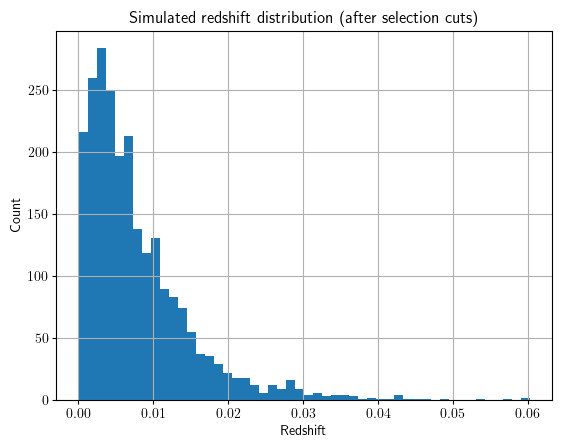

In [14]:
# redshift distribution of simulated SNe (post-cuts)
fig, ax = plt.subplots()
lightcurves_after_quality_cut["source_redshift"].hist(bins=50, ax=ax)
ax.set(xlabel="Redshift", ylabel="Count", title="Simulated redshift distribution (after selection cuts)")
plt.show()

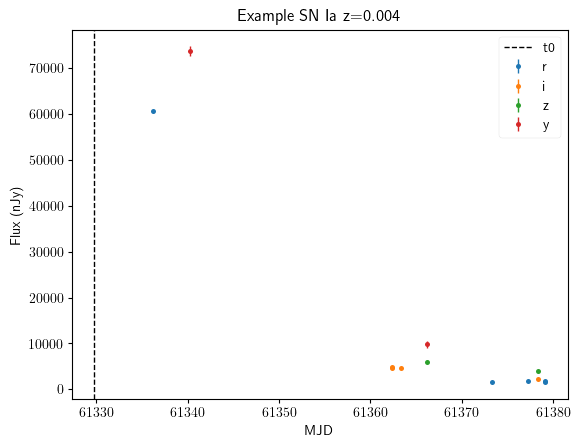

In [15]:
# example light curve for a single SN (post-cuts)
sn = lightcurves_after_quality_cut.iloc[np.random.choice(len(lightcurves_after_quality_cut))]
lc = sn["lightcurve"]
for band in SIM_PARAMS["filters"]:
    mask = lc["filter"] == band
    mask &= (lc["mjd"] - sn["source_t0"]) / (1.0 + sn["source_redshift"]) > -20
    mask &= (lc["mjd"] - sn["source_t0"]) / (1.0 + sn["source_redshift"]) < 100
    if mask.any():
        plt.errorbar(lc["mjd"][mask], lc["flux"][mask], lc["fluxerr"][mask],
                     fmt="o", label=band, capsize=3)
plt.axvline(sn["source_t0"], ls="--", color="k", label="t0")
plt.legend()
plt.xlabel("MJD")
plt.ylabel("Flux (nJy)")
plt.title(f'Example SN Ia  z={sn["source_redshift"]:.3f}')
plt.show()

## 11. Save Results

In [16]:
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

# results.to_parquet(output_dir / "lsst_kn_v501_results.parquet")
# print(f"Saved all simulated SNe to {output_dir / 'lsst_kn_v501_results.parquet'}")

lightcurves_after_quality_cut.to_parquet(output_dir / "lsst_kn_v501_after_cuts.parquet")
print(f"Saved post-cut SNe to {output_dir / 'lsst_kn_v501_after_cuts.parquet'}")

Saved post-cut SNe to output/lsst_kn_v501_after_cuts.parquet
